In [1]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load cleaned daily temperature dataset
# ------------------------------------------------------------

df = pd.read_csv("clean_daily_temperatures.csv")
print("Initial rows loaded:", len(df))

# Format dates and create year/month columns
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# Make sure temperature columns are numeric
df["TMIN_C"] = pd.to_numeric(df["TMIN_C"], errors="coerce")
df["TMAX_C"] = pd.to_numeric(df["TMAX_C"], errors="coerce")

# ------------------------------------------------------------
# Filter to summer: June, July, August, September
# ------------------------------------------------------------

summer_df = df[df["month"].isin([6, 7, 8, 9])].copy()

print("Summer rows before dropping missing TMIN:", len(summer_df))

# ------------------------------------------------------------
# Define baseline period
# ------------------------------------------------------------

BASELINE_START = 1981
BASELINE_END = 2010

baseline_df = summer_df[
    (summer_df["year"] >= BASELINE_START) &
    (summer_df["year"] <= BASELINE_END)
].copy()

print("Baseline summer rows:", len(baseline_df))

# ------------------------------------------------------------
# Compute station-specific baseline thresholds and climatologies
# ------------------------------------------------------------

station_baseline = (
    baseline_df
    .groupby("station_id")
    .agg(
        # Station metadata
        station_name=("station_name", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        elevation_m=("elevation_m", "first"),

        # Baseline mean summer temperatures
        baseline_summer_TMIN_C=("TMIN_C", "mean"),
        baseline_summer_TMAX_C=("TMAX_C", "mean"),

        # Station-specific 95th percentile thresholds
        TMIN_95_threshold_C=("TMIN_C", lambda x: x.dropna().quantile(0.95)),
        TMAX_95_threshold_C=("TMAX_C", lambda x: x.dropna().quantile(0.95)),

        # Baseline coverage diagnostics
        baseline_valid_TMIN_days=("TMIN_C", "count"),
        baseline_valid_TMAX_days=("TMAX_C", "count"),
    )
    .reset_index()
)

print("Stations with baseline thresholds:", len(station_baseline))

# Optional but recommended: remove stations with poor baseline coverage
# June-Sept has ~122 days/year, so 30 years has about 3660 possible summer days.
expected_baseline_summer_days = 122 * (BASELINE_END - BASELINE_START + 1)
min_baseline_days = int(0.80 * expected_baseline_summer_days)

station_baseline = station_baseline[
    (station_baseline["baseline_valid_TMIN_days"] >= min_baseline_days) &
    (station_baseline["baseline_valid_TMAX_days"] >= min_baseline_days)
].copy()

print("Stations after baseline coverage filter:", len(station_baseline))

# ------------------------------------------------------------
# Merge station-specific thresholds back into summer data
# ------------------------------------------------------------

summer_df = summer_df.merge(
    station_baseline[
        [
            "station_id",
            "baseline_summer_TMIN_C",
            "baseline_summer_TMAX_C",
            "TMIN_95_threshold_C",
            "TMAX_95_threshold_C",
        ]
    ],
    on="station_id",
    how="inner"   # inner keeps only stations with valid baseline thresholds
)

# ------------------------------------------------------------
# Define warm nights and hot days using station-specific thresholds
# ------------------------------------------------------------

# Drop rows with missing TMIN before defining warm nights
summer_df["valid_TMIN"] = summer_df["TMIN_C"].notna()
summer_df["valid_TMAX"] = summer_df["TMAX_C"].notna()

summer_df["is_warm_night"] = (
    summer_df["valid_TMIN"] &
    (summer_df["TMIN_C"] > summer_df["TMIN_95_threshold_C"])
).astype(int)

summer_df["is_hot_day"] = (
    summer_df["valid_TMAX"] &
    (summer_df["TMAX_C"] > summer_df["TMAX_95_threshold_C"])
).astype(int)

print("Summer rows after merging baseline thresholds:", len(summer_df))
print(summer_df[["station_id", "date", "TMIN_C", "TMIN_95_threshold_C", "is_warm_night"]].head())

C:\Users\Maike\AppData\Local\Temp\ipykernel_17168\3935430180.py:8: DtypeWarning: Columns (0: TAVG_ATTRIBUTES) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clean_daily_temperatures.csv")


Initial rows loaded: 6140812
Summer rows before dropping missing TMIN: 2053228
Baseline summer rows: 1158359
Stations with baseline thresholds: 369
Stations after baseline coverage filter: 230
Summer rows after merging baseline thresholds: 1461415
    station_id       date  TMIN_C  TMIN_95_threshold_C  is_warm_night
0  USC00040136 1970-06-01    11.7                 22.2              0
1  USC00040136 1970-06-02    18.3                 22.2              0
2  USC00040136 1970-06-03    13.9                 22.2              0
3  USC00040136 1970-06-04    12.2                 22.2              0
4  USC00040136 1970-06-05    11.7                 22.2              0


In [2]:
# ------------------------------------------------------------
# Aggregate to station-year level
# ------------------------------------------------------------

station_year = (
    summer_df
    .groupby(["station_id", "year"])
    .agg(
        station_name=("station_name", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        elevation_m=("elevation_m", "first"),

        baseline_summer_TMIN_C=("baseline_summer_TMIN_C", "first"),
        baseline_summer_TMAX_C=("baseline_summer_TMAX_C", "first"),
        TMIN_95_threshold_C=("TMIN_95_threshold_C", "first"),
        TMAX_95_threshold_C=("TMAX_95_threshold_C", "first"),

        valid_summer_TMIN_days=("valid_TMIN", "sum"),
        valid_summer_TMAX_days=("valid_TMAX", "sum"),

        warm_night_count=("is_warm_night", "sum"),
        hot_day_count=("is_hot_day", "sum"),

        summer_mean_TMIN_C=("TMIN_C", "mean"),
        summer_mean_TMAX_C=("TMAX_C", "mean"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

station_year["percent_warm_nights"] = (
    100 * station_year["warm_night_count"] / station_year["valid_summer_TMIN_days"]
)

station_year["percent_hot_days"] = (
    100 * station_year["hot_day_count"] / station_year["valid_summer_TMAX_days"]
)

# ------------------------------------------------------------
# Filter out station-years with poor summer coverage
# ------------------------------------------------------------

# June-Sept has 122 possible days. 80% coverage is about 98 days.
MIN_VALID_SUMMER_DAYS = 98

station_year = station_year[
    (station_year["valid_summer_TMIN_days"] >= MIN_VALID_SUMMER_DAYS) &
    (station_year["valid_summer_TMAX_days"] >= MIN_VALID_SUMMER_DAYS)
].copy()

print("Station-year aggregation complete. Total records:", len(station_year))
print("Number of stations:", station_year["station_id"].nunique())
print("Year range:", station_year["year"].min(), "-", station_year["year"].max())

station_year.head()

Station-year aggregation complete. Total records: 10878
Number of stations: 230
Year range: 1970 - 2025


,station_id,year,station_name,latitude,longitude,elevation_m,baseline_summer_TMIN_C,baseline_summer_TMAX_C,TMIN_95_threshold_C,TMAX_95_threshold_C,valid_summer_TMIN_days,valid_summer_TMAX_days,warm_night_count,hot_day_count,summer_mean_TMIN_C,summer_mean_TMAX_C,percent_warm_nights,percent_hot_days
0,USC00040136,1970,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,120,120,2,11,15.192500,32.761667,1.666667,9.166667
2,USC00040136,1972,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,119,119,5,13,15.198319,31.355462,4.201681,10.924370
4,USC00040136,1974,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,113,113,0,5,14.569912,32.748673,0.000000,4.424779
5,USC00040136,1975,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,116,111,0,4,13.402586,31.314414,0.000000,3.603604
6,USC00040136,1976,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,118,117,1,12,14.350847,31.217094,0.847458,10.256410


In [3]:
import geopandas as gpd
from shapely.geometry import Point

print("Calculating distance to coast...")
stations_geo = station_year[['station_id', 'station_name', 'latitude', 'longitude']].drop_duplicates(subset=['station_id'])
gdf_stations = gpd.GeoDataFrame(
    stations_geo,
    geometry=gpd.points_from_xy(stations_geo['longitude'], stations_geo['latitude']),
    crs="EPSG:4326"
)

# Load Natural Earth lowres dataset directly from the official source URL
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
usa = world[world['ADMIN'] == 'United States of America']

usa_projected = usa.to_crs("EPSG:5070") # Albers Equal Area Conic (meters)
gdf_stations_projected = gdf_stations.to_crs("EPSG:5070")

coastline_geom = usa_projected.geometry.unary_union.boundary
gdf_stations['distance_to_coast_km'] = gdf_stations_projected.geometry.distance(coastline_geom) / 1000.0

# Merge back into station_year
station_year = station_year.merge(
    gdf_stations[['station_id', 'distance_to_coast_km']],
    on='station_id',
    how='left'
)

print("Distance to coast calculation complete.")

Calculating distance to coast...
Distance to coast calculation complete.


C:\Users\Maike\AppData\Local\Temp\ipykernel_17168\989545996.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  coastline_geom = usa_projected.geometry.unary_union.boundary


In [7]:
filtered_dataset = station_year.copy() # we already filtered to correct number of min valid days

output_filename = 'Random_Forest_Modeling_Data.csv'
filtered_dataset.to_csv(output_filename, index=False)
print(f"Dataset saved successfully! Total station-years: {len(filtered_dataset)}")

Dataset saved successfully! Total station-years: 10878


In [8]:
total_stations = filtered_dataset['station_id'].nunique()
total_station_years = len(filtered_dataset)
min_year = filtered_dataset['year'].min()
max_year = filtered_dataset['year'].max()
avg_warm_nights = filtered_dataset['percent_warm_nights'].mean()

station_avg = filtered_dataset.groupby(['station_id', 'station_name'])['percent_warm_nights'].mean().reset_index()
top_stations = station_avg.sort_values(by='percent_warm_nights', ascending=False).head(5)

print("="*40)
print("=== TASK 5 DELIVERABLES SUMMARY ===")
print("="*40)
print(f"• How many stations are included? {total_stations}")
print(f"• How many station-years are included? {total_station_years}")
print(f"• What years are covered? {min_year} - {max_year}")
print(f"• What is the average percent_warm_nights? {avg_warm_nights:.2f}%")
print("\n• Which stations have the highest average percent_warm_nights?")
print(top_stations.to_string(index=False))

predictors_to_check = ['latitude', 'longitude', 'elevation_m', 'distance_to_coast_km', 'percent_warm_nights']
missing_report = filtered_dataset[[col for col in predictors_to_check if col in filtered_dataset.columns]].isnull().sum()
print("\n" + "="*40)
print("=== MISSING VALUE CHECK ===")
print("="*40)
print(missing_report)

=== TASK 5 DELIVERABLES SUMMARY ===
• How many stations are included? 230
• How many station-years are included? 10878
• What years are covered? 1970 - 2025
• What is the average percent_warm_nights? 5.02%

• Which stations have the highest average percent_warm_nights?
 station_id                         station_name  percent_warm_nights
USR0000CSCI  SANTA CRUZ ISLAND CALIFORNIA, CA US            10.146982
USC00042319    DEATH VALLEY NATIONAL PARK, CA US             8.679581
USC00049785 WOODLAND HILLS PIERCE COLLEGE, CA US             8.526671
USS0020K04S             INDEPENDENCE CAMP, CA US             8.378280
USS0019L13S          VIRGINIA LAKES RIDGE, CA US             8.178424

=== MISSING VALUE CHECK ===
latitude                0
longitude               0
elevation_m             0
distance_to_coast_km    0
percent_warm_nights     0
dtype: int64


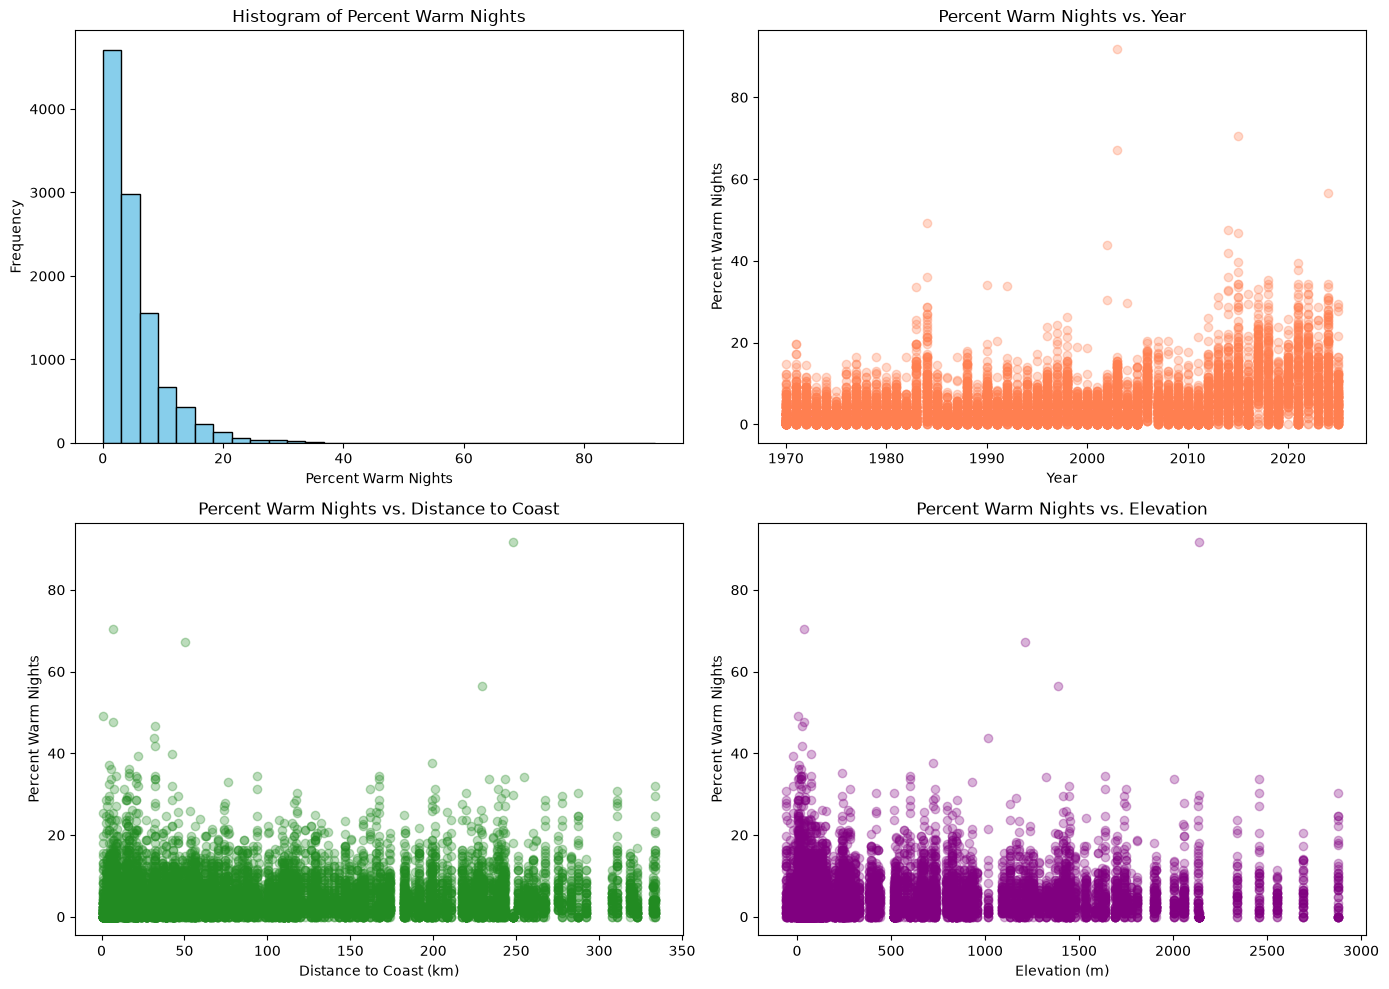

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# 1. Histogram of percent_warm_nights
plt.subplot(2, 2, 1)
plt.hist(filtered_dataset['percent_warm_nights'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Percent Warm Nights')
plt.xlabel('Percent Warm Nights')
plt.ylabel('Frequency')

# 2. Scatterplot: percent_warm_nights vs year
plt.subplot(2, 2, 2)
plt.scatter(filtered_dataset['year'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='coral')
plt.title('Percent Warm Nights vs. Year')
plt.xlabel('Year')
plt.ylabel('Percent Warm Nights')

# 3. Scatterplot: percent_warm_nights vs distance_to_coast_km
plt.subplot(2, 2, 3)
plt.scatter(filtered_dataset['distance_to_coast_km'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='forestgreen')
plt.title('Percent Warm Nights vs. Distance to Coast')
plt.xlabel('Distance to Coast (km)')
plt.ylabel('Percent Warm Nights')

# 4. Scatterplot: percent_warm_nights vs elevation_m
plt.subplot(2, 2, 4)
plt.scatter(filtered_dataset['elevation_m'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='purple')
plt.title('Percent Warm Nights vs. Elevation')
plt.xlabel('Elevation (m)')
plt.ylabel('Percent Warm Nights')

plt.tight_layout()
plt.show()